In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import gc
import os
import h5py
from scipy.optimize import brentq

import sys
sys.path.insert(0, '/beegfs/general/skoudmani/students/kasar/python/')
import utils as util
import snapHDF5 as ws

In [2]:
base_dir_1 = "/beegfs/general/kprofit/binary_tests/al_td_96/output_bhspin/" #change to your directory

plots_dir = "/beegfs/general/kprofit/summer_proj/plots" #change to your directory

UnitLength_in_cm = 3.08568e18
UnitMass_in_g = 4.62681e+35
UnitVelocity_in_cm_per_s = 1e5
UnitTime_in_s = UnitLength_in_cm / UnitVelocity_in_cm_per_s
SolarMass = 1.989e33
Parsec = 3.086e18

positionConversion = UnitLength_in_cm / Parsec
massConversion = UnitMass_in_g / SolarMass
rhoConversion = massConversion / positionConversion**3
velConversion = UnitVelocity_in_cm_per_s / 1.e5

In [3]:
def plot_bhs(p1, p2, ax, bh_hsml):
	ax.plot(p1[0], p1[1], "o", ms=4, mec="b", mfc="b")
	ax.plot(p2[0], p2[1], "o", ms=4, mec="r", mfc="r")
	if bh_hsml != None:
		ax.add_patch(pl.Circle((p1[0], p1[1]), bh_hsml, fill=False, color="b", lw=2))
		ax.add_patch(pl.Circle((p2[0], p2[1]), bh_hsml, fill=False, color="r", lw=2))

def plot_gas_bhs(snap, ax, **kw):
	width = kw.get('width', 30)
	height = kw.get('height', width)
	depth = kw.get('depth', width)
	cmap = kw.get('cmap', 'magma')
	bh_hsml = kw.get('bh_hsml', None)
	vmin = kw.get('vmin', -1)
	vmax = kw.get('vmax', 3.3)
	alignBHs = kw.get('alignBHs', True)
	rotateX = kw.get('rotateX', 0)
	rotateZ = kw.get('rotateZ', 0)
	idbh = ws.read_block(snap, "ID  ", 5)
	posbh = ws.read_block(snap, "POS ", 5) * positionConversion
	massbh = ws.read_block(snap, "MASS", 5) * massConversion
	posg = ws.read_block(snap, "POS ", 0) * positionConversion
	massg = ws.read_block(snap, "MASS", 0) * massConversion
	rhog = ws.read_block(snap, "RHO ", 0) * rhoConversion
	com = util.getCoM(posbh, massbh)
	posbh -= com
	posg -= com
	
	bh0 = np.where(idbh == min(idbh))[0][0]
	bh1 = np.where(idbh == max(idbh))[0][0]

	p1 = posbh[bh0]
	p2 = posbh[bh1]

	angle = 0
	if alignBHs == True:
		angle = -np.arctan2((p2 - p1)[1], (p2 - p1)[0])
	elif rotateZ !=0:
		angle = rotateZ

	if angle !=0:
		posbh = util.rotate(posbh, angle, 2)
		posg = util.rotate(posg, angle, 2)
		p1 = posbh[bh0]
		p2 = posbh[bh1]
	
	if rotateX != 0:
		posbh = util.rotate(posbh, rotateX, 0)
		posg = util.rotate(posg, rotateX, 0)
		p1 = posbh[bh0]
		p2 = posbh[bh1]

	Xmin = -width / 2
	Xmax = width / 2
	Ymin = -height / 2
	Ymax = height / 2
	inc = util.cutCubeIndices(posg, Xmin)

	Image = util.doProjection(posg[inc], massg[inc], rhog[inc], 512, 512, width, height, depth) #can change pixel number here

	ax.imshow(np.log10(Image),extent=[Xmin, Xmax, Ymin, Ymax], cmap=cmap, origin="lower", vmin=vmin, vmax=vmax, rasterized=False)
	plot_bhs(p1, p2, ax, bh_hsml)
	return [posbh, posg, angle]

def preprocess_snapshot(sim):
	com_bbh = np.sum(sim.bh["pos"] * sim.bh["mass"][:, None], axis=0) / np.sum(sim.bh["mass"])
	vcom_bbh = np.sum(sim.bh["vel"] * sim.bh["mass"][:, None], axis=0) / np.sum(sim.bh["mass"])

	# Centre of mass of the binary
	sim["pos"] -= com_bbh
	sim["vel"] -= vcom_bbh
	
	# Rotate the snapshot such as the binary lies on the x axis
	p1 = sim.bh["pos"][sim.bh["iord"].argmin(), :]
	p2 = sim.bh["pos"][sim.bh["iord"].argmax(), :]
	
	angle = -np.arctan2((p2 - p1)[1], (p2 - p1)[0]) * 180. / np.pi
	
	sim.rotate_z(angle)
	
	return

In [12]:
def summary_map():

	sim_name = [r"$\rm t=0$",
                r"$\rm t=t_2$"
				]
	
	filename = [base_dir_1 + "snapshot_000",			
				base_dir_1 + "snapshot_201"]
	
	NCOLS = 2
	NROWS = 1
	
	l = 3.
	Lx = NCOLS * l + 1.0
	Ly = NROWS * l + 1.8
	
	fig = plt.figure(figsize=(Lx,Ly))
	
	AxGrid = []
	
	for i in range(NROWS):
		for j in range(NCOLS):
			k = j + i * NCOLS
			
			AxGrid.append(fig.add_axes([(0.9 + j*l)/Lx, (Ly - 1.1 - (i + 1) * l)/Ly, l/Lx, l/Ly]))
			ax = AxGrid[-1]
			
			if k < NCOLS*1.5:
				plot_gas_bhs(filename[k], ax)	
				print("- Density map", k+1, "done")
			
			ax.text(-13, 12, sim_name[k], fontsize=16, color="w")	
			ax.minorticks_on()
			ax.set_xlim([-15, 15])
			ax.set_ylim([-15, 15])
			ax.set_xticks(np.arange(-15,15,5))
			ax.set_yticks(np.arange(-15,15,5))
            
			ax.tick_params(labelsize=14)
			
			if i < 0:#==0
				ax.set_xticklabels("")
			else:
				ax.set_xlabel(r"$x~{\rm (pc)}$",fontsize=16)
			
			if j == 0:
				ax.set_ylabel(r"$y~{\rm (pc)}$",fontsize=16)
			else:
				ax.set_yticklabels("")
	
	# Colour bar
	ax_cb = fig.add_axes([(0.9)/Lx, (Ly - 1.0)/Ly, NCOLS*l/Lx, 0.1*l/Ly])
	ax_cb.minorticks_on()
	norm = mpl.colors.Normalize(vmin=-1, vmax=3.3)
	cmap = mpl.cm.magma
	cb = mpl.colorbar.ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation="horizontal", ticks=np.arange(-1., 3.1, 1.))
	cb.set_label(r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$", labelpad=5, fontsize=16)
	cb.ax.xaxis.set_ticks_position('top')
	cb.ax.xaxis.set_label_position('top')
	
	plt.savefig("%s/CBDISC_MAPS_96.png" %plots_dir, bbox_inches="tight",dpi=800)
	
	plt.show()
	return

0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49546
0 49538
- Density map 1 done
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49308
0 49292
- Density map 2 done


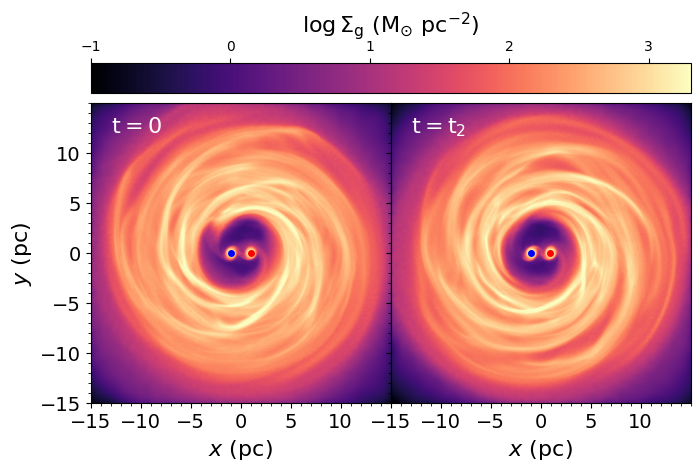

In [13]:
summary_map()


In [6]:
def plot_bhs(p1, p2, ax, bh_hsml):
	ax.plot(p1[0], p1[1], "o", ms=4, mec="b", mfc="b")
	ax.plot(p2[0], p2[1], "o", ms=4, mec="r", mfc="r")
	if bh_hsml != None:
		ax.add_patch(pl.Circle((p1[0], p1[1]), bh_hsml, fill=False, color="b", lw=2))
		ax.add_patch(pl.Circle((p2[0], p2[1]), bh_hsml, fill=False, color="r", lw=2))

def plot_gas_bhs(snap, ax, **kw):
	width = kw.get('width', 10)
	height = kw.get('height', width)
	depth = kw.get('depth', width)
	cmap = kw.get('cmap', 'cividis')
	bh_hsml = kw.get('bh_hsml', None)
	vmin = kw.get('vmin', -1)
	vmax = kw.get('vmax', 3.3)
	alignBHs = kw.get('alignBHs', True)
	rotateX = kw.get('rotateX', 0)
	rotateZ = kw.get('rotateZ', 0)
	idbh = ws.read_block(snap, "ID  ", 5)
	posbh = ws.read_block(snap, "POS ", 5) * positionConversion
	massbh = ws.read_block(snap, "MASS", 5) * massConversion
	posg = ws.read_block(snap, "POS ", 0) * positionConversion
	massg = ws.read_block(snap, "MASS", 0) * massConversion
	rhog = ws.read_block(snap, "RHO ", 0) * rhoConversion
	com = util.getCoM(posbh, massbh)
	posbh -= com
	posg -= com
	
	bh0 = np.where(idbh == min(idbh))[0][0]
	bh1 = np.where(idbh == max(idbh))[0][0]

	p1 = posbh[bh0]
	p2 = posbh[bh1]

	angle = 0
	if alignBHs == True:
		angle = -np.arctan2((p2 - p1)[1], (p2 - p1)[0])
	elif rotateZ !=0:
		angle = rotateZ

	if angle !=0:
		posbh = util.rotate(posbh, angle, 2)
		posg = util.rotate(posg, angle, 2)
		p1 = posbh[bh0]
		p2 = posbh[bh1]
	
	if rotateX != 0:
		posbh = util.rotate(posbh, rotateX, 0)
		posg = util.rotate(posg, rotateX, 0)
		p1 = posbh[bh0]
		p2 = posbh[bh1]

	Xmin = -width / 2
	Xmax = width / 2
	Ymin = -height / 2
	Ymax = height / 2
	inc = util.cutCubeIndices(posg, Xmin)

	Image = util.doProjection(posg[inc], massg[inc], rhog[inc], 512, 512, width, height, depth) #can change pixel number here

	ax.imshow(np.log10(Image),extent=[Xmin, Xmax, Ymin, Ymax], cmap=cmap, origin="lower", vmin=vmin, vmax=vmax, rasterized=False)
	plot_bhs(p1, p2, ax, bh_hsml)
	return [posbh, posg, angle]

def preprocess_snapshot(sim):
	com_bbh = np.sum(sim.bh["pos"] * sim.bh["mass"][:, None], axis=0) / np.sum(sim.bh["mass"])
	vcom_bbh = np.sum(sim.bh["vel"] * sim.bh["mass"][:, None], axis=0) / np.sum(sim.bh["mass"])

	# Centre of mass of the binary
	sim["pos"] -= com_bbh
	sim["vel"] -= vcom_bbh
	
	# Rotate the snapshot such as the binary lies on the x axis
	p1 = sim.bh["pos"][sim.bh["iord"].argmin(), :]
	p2 = sim.bh["pos"][sim.bh["iord"].argmax(), :]
	
	angle = -np.arctan2((p2 - p1)[1], (p2 - p1)[0]) * 180. / np.pi
	
	sim.rotate_z(angle)
	
	return

In [7]:
def summary_map():

	sim_name = [r"$\rm t=0$",
                r"$\rm t=t_2$"
				]
	
	filename = [base_dir_1 + "snapshot_000",			
				base_dir_1 + "snapshot_201"]
	
	NCOLS = 2
	NROWS = 1
	
	l = 3.
	Lx = NCOLS * l + 1.0
	Ly = NROWS * l + 1.0
	
	fig = plt.figure(figsize=(Lx,Ly))
	
	AxGrid = []
	
	for i in range(NROWS):
		for j in range(NCOLS):
			k = j + i * NCOLS
			
			AxGrid.append(fig.add_axes([(0.9 + j*l)/Lx, (Ly - 1.1 - (i + 1) * l)/Ly, l/Lx, l/Ly]))
			ax = AxGrid[-1]
			
			if k < NCOLS*1.5:
				width = 10
				plot_gas_bhs(filename[k], ax, width = width)	
				print("- Density map", k+1, "done")
			
			ax.text(-13, 12, sim_name[k], fontsize=16, color="w")	
			ax.minorticks_on()
			#ax.set_xlim([-5, 5])
			#ax.set_ylim([-5, 5])
			ax.set_xlim([-width/2, width/2])
			ax.set_ylim([-width/2, width/2])
			ax.set_xticks(np.arange(-5,6,1))
			ax.set_yticks(np.arange(-5,6,1))
            
			ax.tick_params(labelsize=14)
			
			if i < 0:#==0
				ax.set_xticklabels("")
			else:
				ax.set_xlabel(r"$x~{\rm (pc)}$",fontsize=16)
			
			if j == 0:
				ax.set_ylabel(r"$y~{\rm (pc)}$",fontsize=16)
			else:
				ax.set_yticklabels("")
	
	# Colour bar
	ax_cb = fig.add_axes([(0.9)/Lx, (Ly - 1.0)/Ly, NCOLS*l/Lx, 0.1*l/Ly])
	ax_cb.minorticks_on()
	norm = mpl.colors.Normalize(vmin=-1, vmax=3.3)
	cmap = mpl.cm.cividis
	cb = mpl.colorbar.ColorbarBase(ax_cb, cmap=cmap, norm=norm, orientation="horizontal", ticks=np.arange(-1., 3.1, 1.))
	cb.set_label(r"$\log \Sigma_{\rm g}~{\rm (M_{\odot}~pc^{-2})}$", labelpad=5, fontsize=16)
	cb.ax.xaxis.set_ticks_position('top')
	cb.ax.xaxis.set_label_position('top')
	
	plt.savefig("%s/CBDISC_MAPS_zoom.png" %plots_dir, bbox_inches="tight",dpi=800)
	plt.show()
	return

0 13501
0 13501
0 13501
0 13501
00 13501
 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13501
0 13493
- Density map 1 done
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
00 13636
 13636
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
0 13636
- Density map 2 done


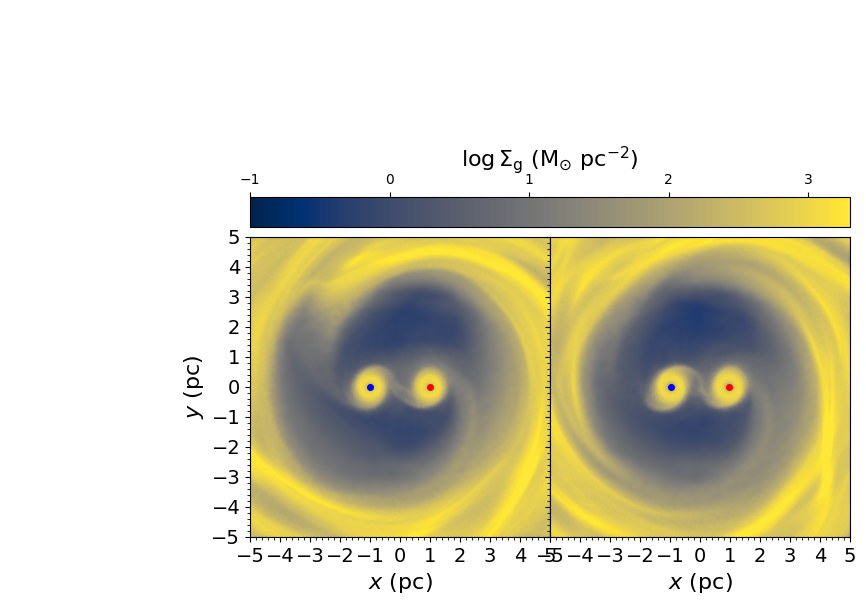

In [8]:
summary_map()
